In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
athletes = pd.read_csv ("..//data/raw/athlete_events.csv")
regions = pd.read_csv ("..//data/raw/noc_regions.csv")

In [4]:
athletes.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [5]:
regions.head()

,NOC,region,notes
0,AFG,Afghanistan,NaN
1,AHO,Curacao,Netherlands Antilles
2,ALB,Albania,NaN
3,ALG,Algeria,NaN
4,AND,Andorra,NaN


## Data cleaning and Transformation

Here, we clean and transform the 120 years of Olymics athlete datasey by merging related tables, filtering the years, renaming the columns, converting measurment units, and preparing the data for analysis 


In [6]:
athletes.shape, regions.shape 

((271116, 15), (230, 3))

In [7]:
athletes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [8]:
regions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     230 non-null    object
 1   region  227 non-null    object
 2   notes   21 non-null     object
dtypes: object(3)
memory usage: 5.5+ KB


## Data Inspection

We first inspect the size, structure, and data types of both datasers to understadn their contents and identify issues such as missing values or mismatched columns before merging.

In [9]:
df = pd.merge(athletes, regions, on="NOC", how="left")

In [10]:
df.shape

(271116, 17)

In [11]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [12]:
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

## Data Merging

The athlete dataset was merged with the NOC regions dataset using the `NOC` column as the key. A left join was used to retain all athlete records while appending regional information where available.

In [13]:
df.shape
df.head()
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64

In [14]:
df = df.rename(columns={
    "Weight": "Weight_kg",
    "Height": "Height_cm"
})

In [15]:
df["Weight_lbs"] = (df["Weight_kg"] * 2.20462).round()
df["Height_in"] = (df["Height_cm"] * 0.393701).round()

In [16]:
df = df[(df["Year"] >= 1996) & (df["Year"] <= 2016)]

In [17]:
df.shape 
df.head()

,ID,Name,Sex,Age,Height_cm,Weight_kg,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes,Weight_lbs,Height_in
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN,132.0,67.0
28,9,Antti Sami Aalto,M,26.0,186.0,96.0,Finland,FIN,2002 Winter,2002,Winter,Salt Lake City,Ice Hockey,Ice Hockey Men's Ice Hockey,NaN,Finland,NaN,212.0,73.0
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN,Finland,NaN,154.0,68.0
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN,122.0,63.0
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN,Finland,NaN,122.0,63.0


## Data Transformation

This dataset was transformed by renaming measurement columns to reflect their units, converting weight and height into alternative units (pounds and inches), and filtering the dataset to include Olympic events between 1996 and 2016.

In [18]:
df["Medal"] = df["Medal"].fillna("No Medal")

Missing values in the Medal column were replaced with "No Medal" since missing values indicate that the athlete did not win a medal.

In [19]:
df = df.drop(columns=["notes"])

The notes column was dropped due to a high proportion of missing values, making it unsuitable for meaningful analysis.

In [20]:
df["region"] = df["region"].fillna("Unknown")

Missing values in the region column were filled with "Unknown" since the number of missing entries was minimal.

In [21]:
df[["Age", "Height_cm", "Weight_kg"]].describe()

,Age,Height_cm,Weight_kg
count,102630.000000,99977.000000,99526.000000
mean,25.687314,175.794223,71.097383
std,5.436733,10.995916,15.305417
min,12.000000,133.000000,28.000000
25%,22.000000,168.000000,60.000000
50%,25.000000,176.000000,70.000000
75%,29.000000,183.000000,80.000000
max,71.000000,226.000000,214.000000


In [22]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Height_cm"] = df["Height_cm"].fillna(df["Height_cm"].median())
df["Weight_kg"] = df["Weight_kg"].fillna(df["Weight_kg"].median())

In [23]:
df["Weight_lbs"] = (df["Weight_kg"] * 2.20462).round()
df["Height_in"] = (df["Height_cm"] * 0.393701).round()

Missing values in Age, Height, and Weight were replaced using the median of each column. Median imputation was chosen to reduce the impact of outliers and preserve the distribution of the data.

In [ ]:
df.isna().sum()

ID              0
Name            0
Sex             0
Age             0
Height_cm       0
Weight_kg       0
Team            0
NOC             0
Games           0
Year            0
Season          0
City            0
Sport           0
Event           0
Medal           0
region        203
Weight_lbs      0
Height_in       0
dtype: int64

In [ ]:
df["region"] = df["region"].fillna("Unknown")

In [ ]:
df.isna().sum()

ID            0
Name          0
Sex           0
Age           0
Height_cm     0
Weight_kg     0
Team          0
NOC           0
Games         0
Year          0
Season        0
City          0
Sport         0
Event         0
Medal         0
region        0
Weight_lbs    0
Height_in     0
dtype: int64

Remaining missing values in the region column were filled with "Unknown" to ensure completeness of the dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
(df["Age"] < 0).sum()
(df["Height_cm"] <= 0).sum()
(df["Weight_kg"] <= 0).sum()

np.int64(0)

In [ ]:
df["Has_Medal"] = df["Medal"].apply(lambda x: 0 if x == "No Medal" else 1)

In [29]:
df.head()

,ID,Name,Sex,Age,Height_cm,Weight_kg,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Weight_lbs,Height_in
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No Medal,China,132.0,67.0
28,9,Antti Sami Aalto,M,26.0,186.0,96.0,Finland,FIN,2002 Winter,2002,Winter,Salt Lake City,Ice Hockey,Ice Hockey Men's Ice Hockey,No Medal,Finland,212.0,73.0
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,No Medal,Finland,154.0,68.0
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,No Medal,Finland,122.0,63.0
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,No Medal,Finland,122.0,63.0


In [ ]:
df.to_csv("../data/cleaned/cleaned_olympics_data.csv", index=False)

## Exploratory Data Analysis

In [44]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 102643 entries, 1 to 271115
Data columns (total 18 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          102643 non-null  int64  
 1   Name        102643 non-null  object 
 2   Sex         102643 non-null  object 
 3   Age         102643 non-null  float64
 4   Height_cm   102643 non-null  float64
 5   Weight_kg   102643 non-null  float64
 6   Team        102643 non-null  object 
 7   NOC         102643 non-null  object 
 8   Games       102643 non-null  object 
 9   Year        102643 non-null  int64  
 10  Season      102643 non-null  object 
 11  City        102643 non-null  object 
 12  Sport       102643 non-null  object 
 13  Event       102643 non-null  object 
 14  Medal       102643 non-null  object 
 15  region      102643 non-null  object 
 16  Weight_lbs  102643 non-null  float64
 17  Height_in   102643 non-null  float64
dtypes: float64(5), int64(2), object(11)
memory usage:

,ID,Age,Height_cm,Weight_kg,Year,Weight_lbs,Height_in
count,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000,102643.000000
mean,68977.641836,25.687227,175.799567,71.064059,2006.053116,156.633224,69.231911
std,39141.008416,5.436394,10.852223,15.072406,6.619310,33.226379,4.277489
min,2.000000,12.000000,133.000000,28.000000,1996.000000,62.000000,52.000000
25%,35476.500000,22.000000,168.000000,60.000000,2000.000000,132.000000,66.000000
50%,69173.000000,25.000000,176.000000,70.000000,2006.000000,154.000000,69.000000
75%,102725.500000,29.000000,183.000000,80.000000,2012.000000,176.000000,72.000000
max,135571.000000,71.000000,226.000000,214.000000,2016.000000,472.000000,89.000000


Summarize the data - DONE
Get basic statistics on the data - DONE
Get value counts of a categorical column - DONE
Get histograms of numeric columns - DONE
Look for relationships and patterns in the data

### Histograms for all of the numeric colummns
For this, we are ignoring displaying the histograms for Height_cm and Weight_kg columns, as they are later translated to US Metrics

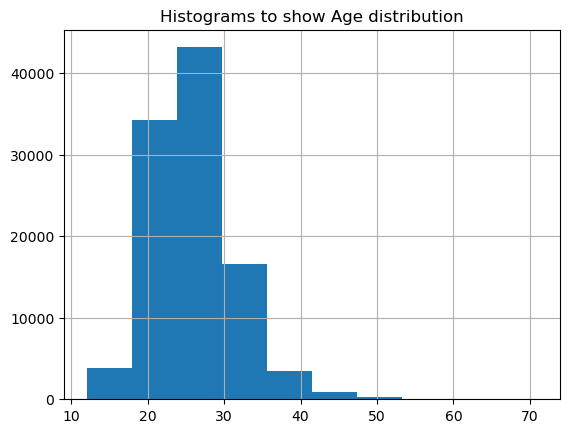

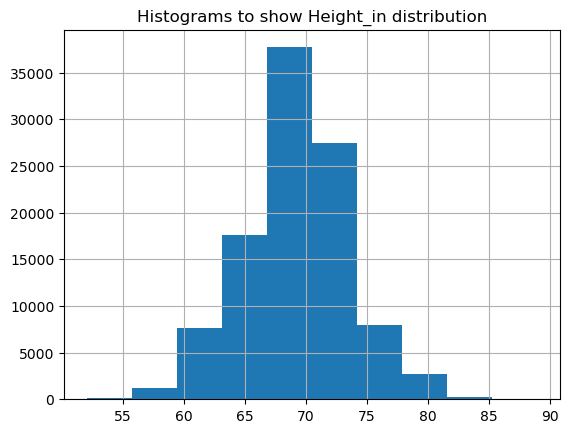

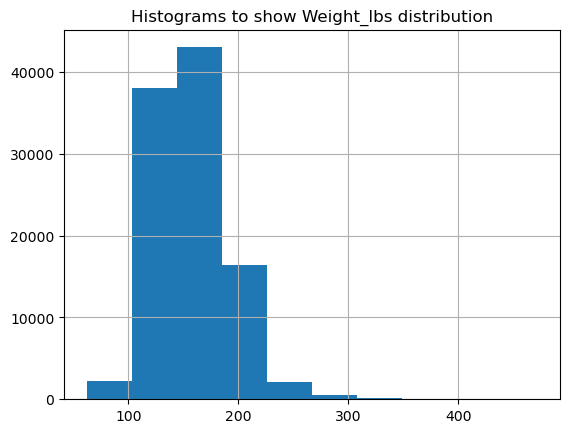

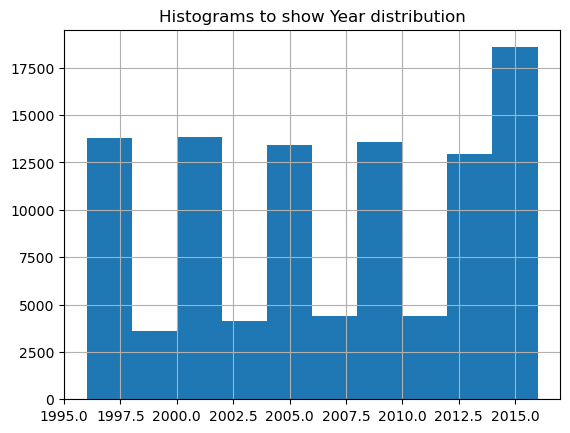

In [28]:
numeric_cols = ["Age", "Height_in", "Weight_lbs", "Year"]

for col in numeric_cols:
    plt.figure()
    df[col].hist()
    plt.title(f"Histograms to show {col} distribution")
    plt.show()

### Value counts for all of the categorical colummns


In [32]:
df["Sport"].value_counts()
#categories = ["Sex", "Team", "Season", "Event", "region"]

#for col in categories:
 #   print(df[col].value_counts())


Sport
Athletics                    14059
Swimming                      9849
Gymnastics                    6397
Cross Country Skiing          3809
Cycling                       3776
Shooting                      3461
Rowing                        3404
Biathlon                      3044
Alpine Skiing                 3027
Canoeing                      2752
Football                      2613
Sailing                       2420
Judo                          2328
Ice Hockey                    2199
Hockey                        2186
Wrestling                     2085
Fencing                       2083
Equestrianism                 2054
Handball                      1994
Boxing                        1791
Speed Skating                 1780
Basketball                    1712
Volleyball                    1690
Tennis                        1572
Table Tennis                  1501
Weightlifting                 1498
Water Polo                    1410
Badminton                     1231
Archery       

### Identifying most popular sport by enrollment count

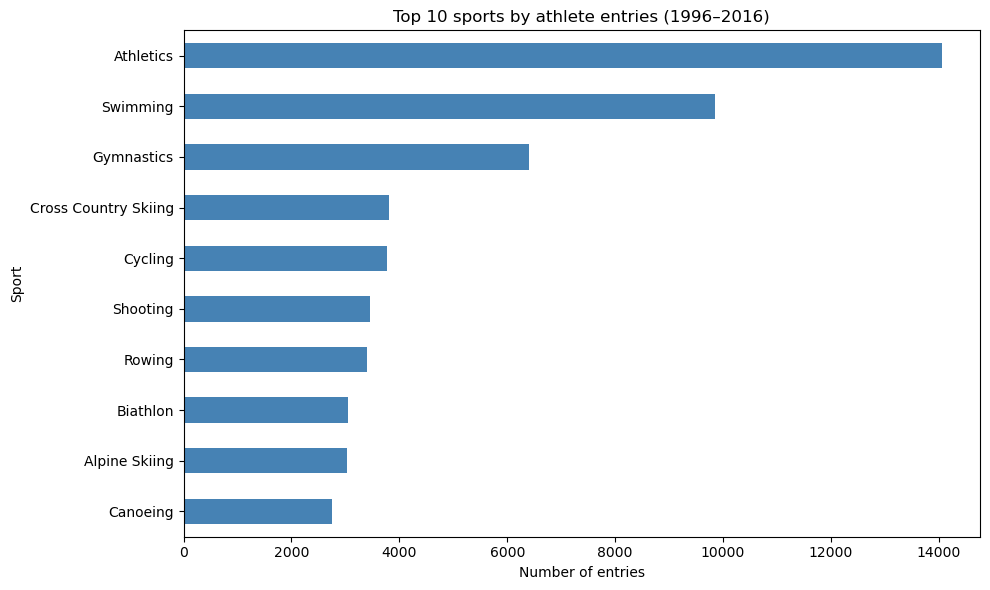

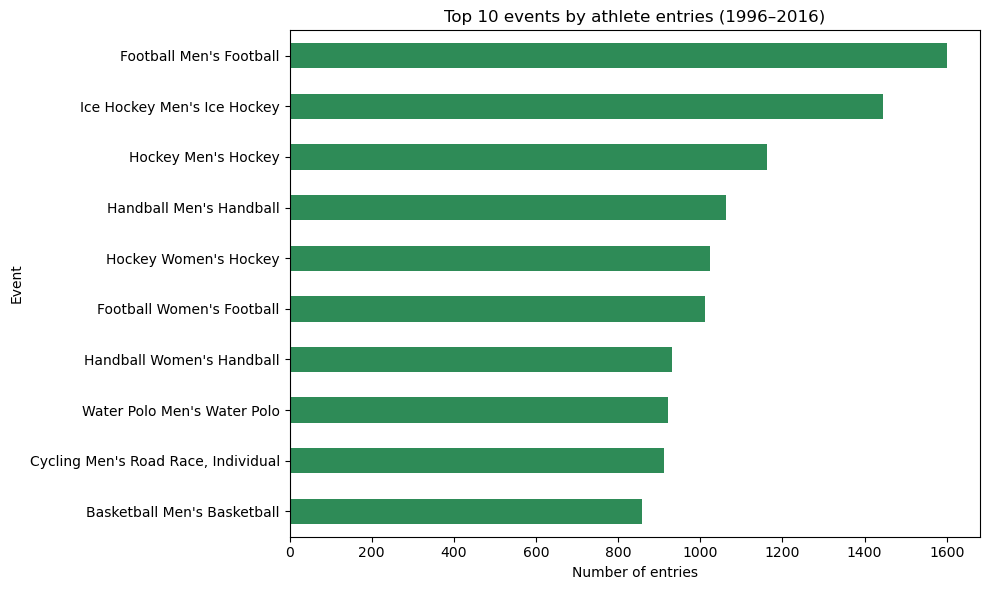

In [33]:
# Top 10 sports
top_sports = df["Sport"].value_counts().head(10)

top_sports.plot(kind="barh", figsize=(10, 6), color="steelblue")
plt.title("Top 10 sports by athlete entries (1996–2016)")
plt.xlabel("Number of entries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 events
top_events = df["Event"].value_counts().head(10)

top_events.plot(kind="barh", figsize=(10, 6), color="seagreen")
plt.title("Top 10 events by athlete entries (1996–2016)")
plt.xlabel("Number of entries")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Identifying the most popular trend per season

In this, we are comparing the popularity of sports comparing the oldest and most recent seasonal olympics 

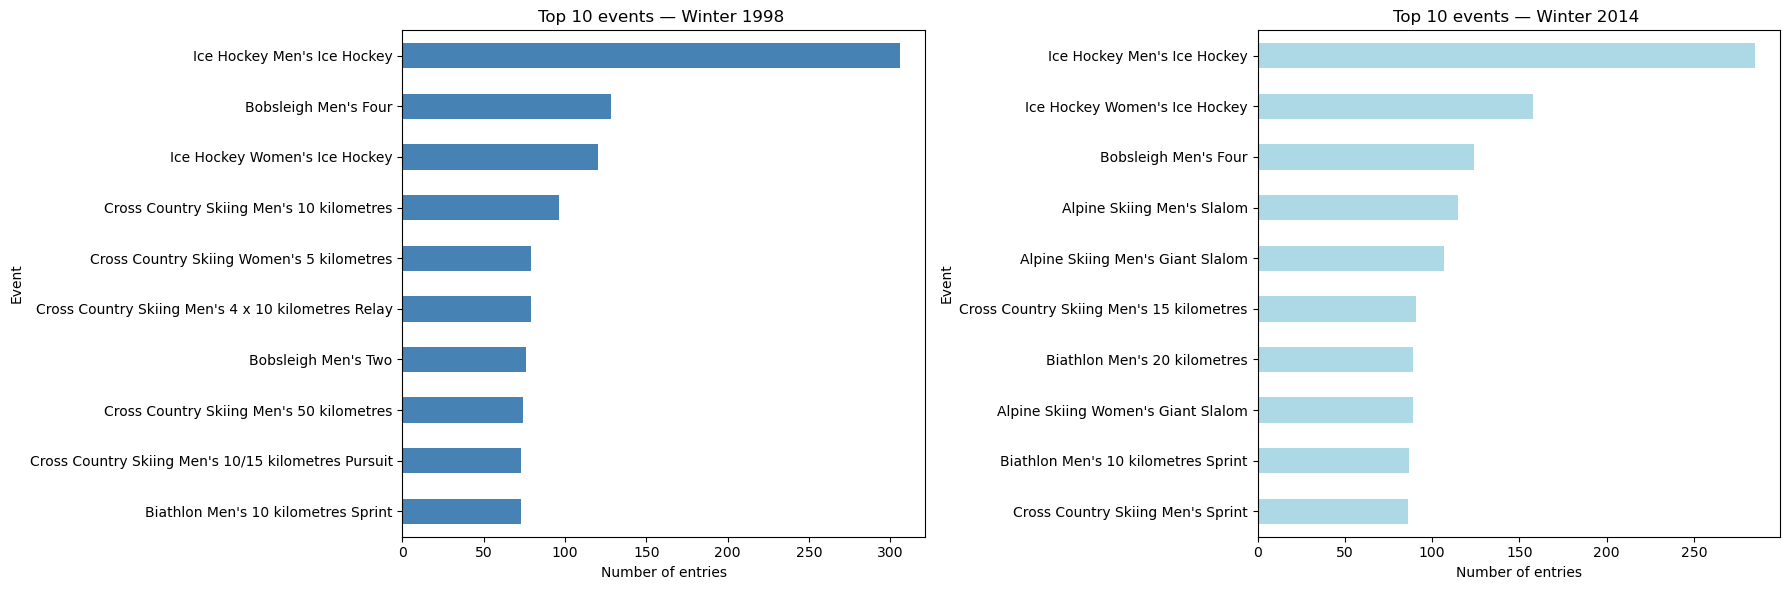

In [37]:
df_1998 = df[df["Year"] == 1998]
df_2014 = df[df["Year"] == 2014]

top_1998 = df_1998["Event"].value_counts().head(10)
top_2014 = df_2014["Event"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_1998.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 events — Winter 1998 ")
axes[0].set_xlabel("Number of entries")

top_2014.sort_values().plot(kind="barh", ax=axes[1], color="lightblue")
axes[1].set_title("Top 10 events — Winter 2014 ")
axes[1].set_xlabel("Number of entries")

plt.tight_layout()
plt.show()

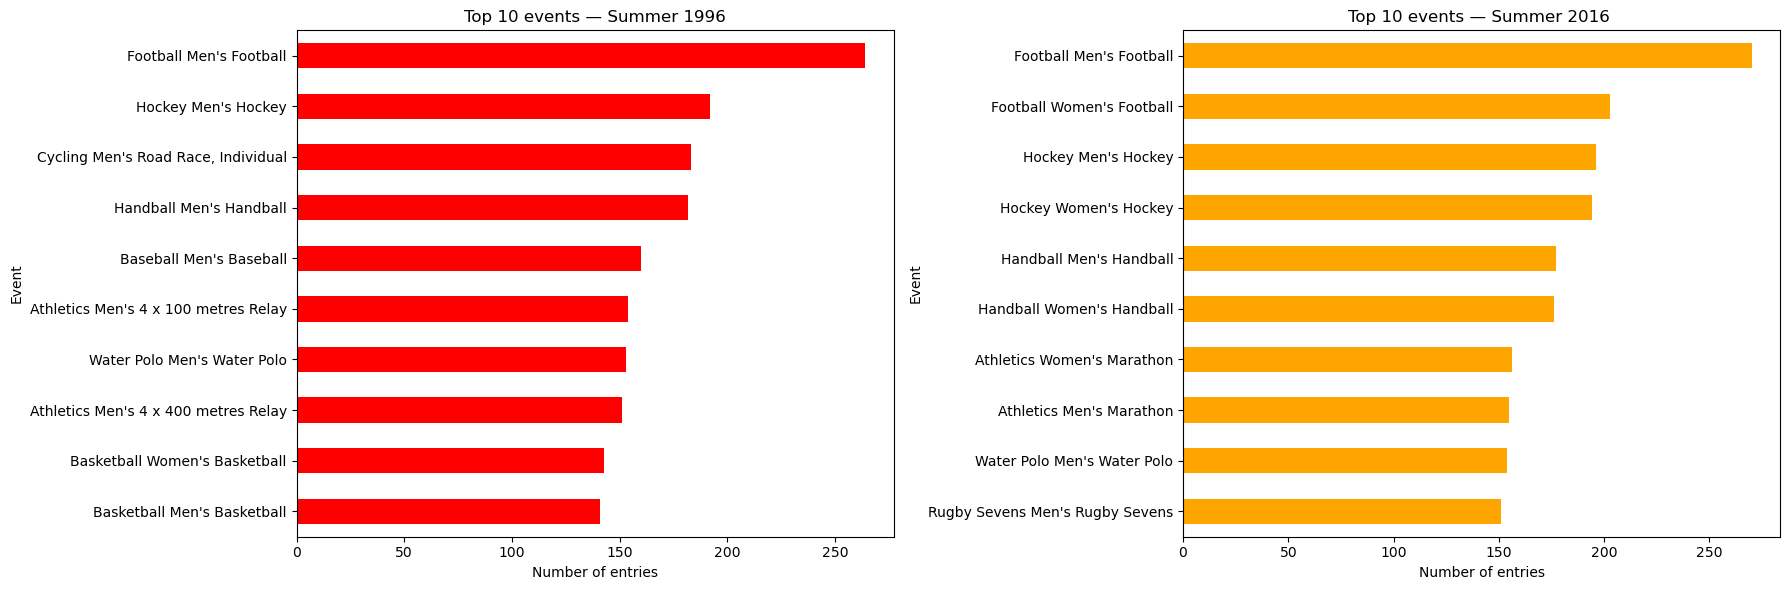

In [42]:
df_1996 = df[df["Year"] == 1996]
df_2016 = df[df["Year"] == 2016]

top_1996 = df_1996["Event"].value_counts().head(10)
top_2016 = df_2016["Event"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_1996.sort_values().plot(kind="barh", ax=axes[0], color="red")
axes[0].set_title("Top 10 events — Summer 1996")
axes[0].set_xlabel("Number of entries")

top_2016.sort_values().plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Top 10 events — Summer 2016 ")
axes[1].set_xlabel("Number of entries")

plt.tight_layout()
plt.show()